In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
import time

# 4.1 The Ising Model in 1d

For the dimensionless version we define the dimensionless $a = \beta J $ and $ b = \beta h$

We get for the true result:

$ Z[a,b] = \lambda_+^N+\lambda_-^N  = \left(e^{a} \left( \cosh(b)+ \sqrt{ \sinh^2(b)+e^{-4a}}\right)\right)^N + \left(e^{a} \left( \cosh(b)- \sqrt{ \sinh^2(b)+e^{-4a}}\right)\right)^N $ 

In [26]:
# Use sympy to solve dZ/dh and calculate M

h, T, J, N = sp.symbols(r'h T J N')
lam_p = sp.exp(J/T)*(sp.cosh(h/T) + sp.sqrt(sp.sinh(h/T)**2+sp.exp(-4*J/T))) # lambda plus
lam_m = sp.exp(J/T)*(sp.cosh(h/T) - sp.sqrt(sp.sinh(h/T)**2+sp.exp(-4*J/T))) # lamnbda minus
Z = lam_p**N+lam_m**N
M = T*sp.diff(sp.log(Z),h)

In [3]:
M.simplify()

N*(((sqrt(sinh(h/T)**2 + exp(-4*J/T)) + cosh(h/T))*exp(J/T))**N - (-(sqrt(sinh(h/T)**2 + exp(-4*J/T)) - cosh(h/T))*exp(J/T))**N)*sqrt(sinh(h/T)**2 + exp(-4*J/T))*exp(4*J/T)*sinh(h/T)/((((sqrt(sinh(h/T)**2 + exp(-4*J/T)) + cosh(h/T))*exp(J/T))**N + (-(sqrt(sinh(h/T)**2 + exp(-4*J/T)) - cosh(h/T))*exp(J/T))**N)*(exp(4*J/T)*sinh(h/T)**2 + 1))

We get the dimensionless version of $\left\langle M \right\rangle$:
\begin{align} 
\left\langle M \right\rangle = N \frac {(\lambda_+^N- (-\lambda_-)^N)\sqrt{\sinh^2(b)+e^{-4a}}e^{4a} \sinh(b)}{(\lambda_+^N + (-\lambda_-)^N)(e^{4a} \sinh^2(b)+1)}
\end{align}
with 

\begin{align} 
\lambda_\pm = \left(e^{a} \left( \cosh(b) \pm \sqrt{ \sinh^2(b)+e^{-4a}}\right)\right)
\end{align}

In [127]:
def M(a,b,N):
    lam_p = np.exp(a)*(np.cosh(b) + np.sqrt(np.sinh(b)**2 + np.exp(-4*a)))
    lam_m = np.exp(a)*(np.cosh(b) - np.sqrt(np.sinh(b)**2 + np.exp(-4*a)))
    diff_Z_1 = N*(lam_p**N - (-lam_m)**N)*np.sqrt(np.sinh(b)**2 + np.exp(-4*a))*np.exp(4*a)*np.sinh(b)
    diff_Z_2 = (lam_p**N + (-lam_m)**N)*(np.exp(4*a)*np.sinh(b)**2 + 1)
    return diff_Z_1/diff_Z_2

def m(a,b):
    return np.sinh(b)/np.sqrt(np.sinh(b)**2+np.exp(-4*a))

J = 0.75  # =a since beta =1
h = np.linspace(-1,1,100)
N = [1,2,4,8,16]


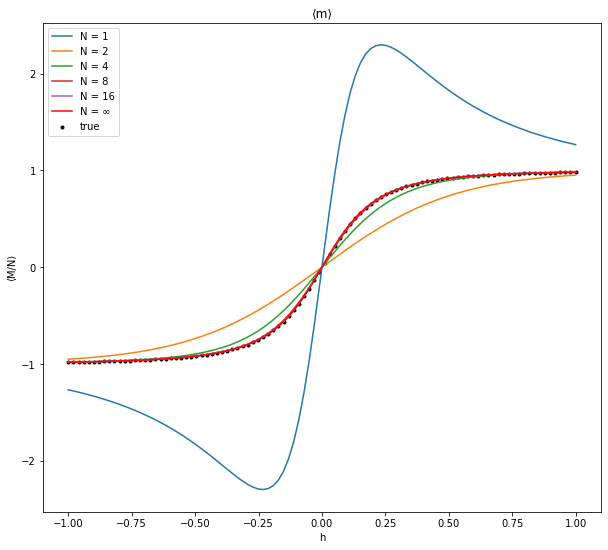

In [130]:
fig,ax =plt.subplots(figsize=(10,9))

for x in range(len(N)):
    ax.plot(h,M(J,h,N[x])/(N[x]) , label = f'N = {N[x]}')
    ax.set_xlabel('h')
    ax.set_ylabel('⟨M/N⟩')
ax.plot(h,M(J,h,300)/300 , label = 'N = ∞', color ='red')
ax.scatter(h,m(J,h), marker ='.', color ='black', label ='true')    
ax.legend(loc='upper left')
ax.set_title('⟨m⟩')
plt.show()
    


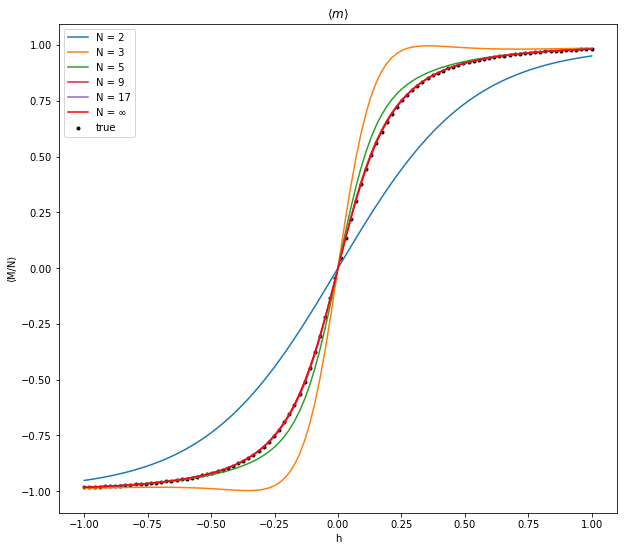

In [131]:
# We were told that for N=1 it should look like for N=2. We suspect, that in the solution is an error, due to an 
# unnecessary index-shift on N. With this shift the solution would look like this

fig,ax =plt.subplots(figsize=(10,9))
for x in range(len(N)):
    ax.plot(h,M(J,h,N[x]+1)/(N[x]+1) , label = f'N = {N[x]+1}')
    ax.set_xlabel('h')
    ax.set_ylabel('⟨M/N⟩')
ax.plot(h,M(J,h,300)/300 , label = 'N = ∞', color ='red')
ax.scatter(h,m(J,h), marker ='.', color ='black', label ='true')    
ax.legend(loc='upper left')
ax.set_title('$⟨m⟩$')
plt.show()

In [132]:
def H1d(a,sigma):
    return -a*(np.roll(sigma,-1)*sigma + np.roll(sigma,1)*sigma).sum()

def action(a,b,sigma):
    S = H1d(a,sigma)-b*sigma.sum()
    return S

In [133]:
def delS1d(a,b,sigma,x):
    if len(sigma)-1 in [x]:
        s = 2*a*(sigma[0]*sigma[x]+ sigma[x-1]*sigma[x])+ 2*b*sigma[x]
    else: 
        s = 2*a*(sigma[x+1]*sigma[x]+ sigma[x-1]*sigma[x])+ 2*b*sigma[x]
    return s

In [21]:
a = 0.75
b = 1
expo = np.arange(1, 10)
N =(10.0**expo)
time1 = np.zeros(len(N))
time2 = np.zeros(len(N))
for s in range(len(N)):
    sigma = np.random.choice([-1,1], size=int(N[s]))
    start1 = time.process_time()
    p = action(a,b,sigma)
    time1[s] = time.process_time() - start1
    start2 = time.process_time()
    p = delS1d(a,b,sigma,1)
    time2[s] = time.process_time() - start2

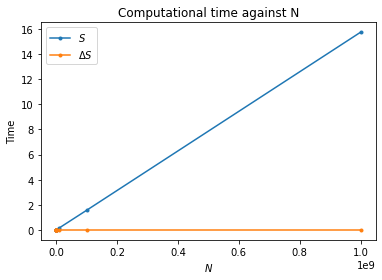

In [22]:
plt.plot(N,time1,marker='.', label='$S$')
plt.plot(N,time2,marker='.', label='$\Delta S$')
plt.title('Computational time against N')
plt.xlabel('$N$')
plt.ylabel('Time')
plt.legend()
plt.show()

In [139]:

def MC_right(J,h,start,steps):
    # start with distribution "start"
    current = start
    m = np.zeros(steps)
    
    for s in range(steps):
        #for each step choose position
        x = np.random.choice(len(start), 1)
        if np.random.uniform(low=0, high=1) < np.exp(-delS1d(J,h,current,x)): # accepting condition
            # if accepted flip a spin
            new = current
            new[x] = -current[x]
        else:
            # else keep current spinconfiguration
            new = current
        current = new
        #calculate M/N
        m[s] = current.sum()/(len(start))
    return m


In [146]:
h = np.linspace(-1,1,20)
steps = 10000
J = 0.75 
sigma =  np.ones(20)
m_h = np.zeros(len(h))
m_std = np.zeros(len(h))
for x in range(len(h)):
    m1 = MC_right(J,h[x],sigma,steps)   
    m_h[x] = m1.mean()
    m_std[x] = m1.std()

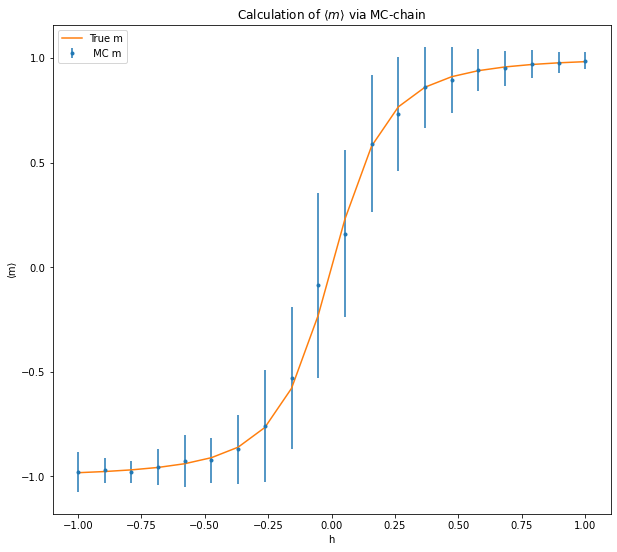

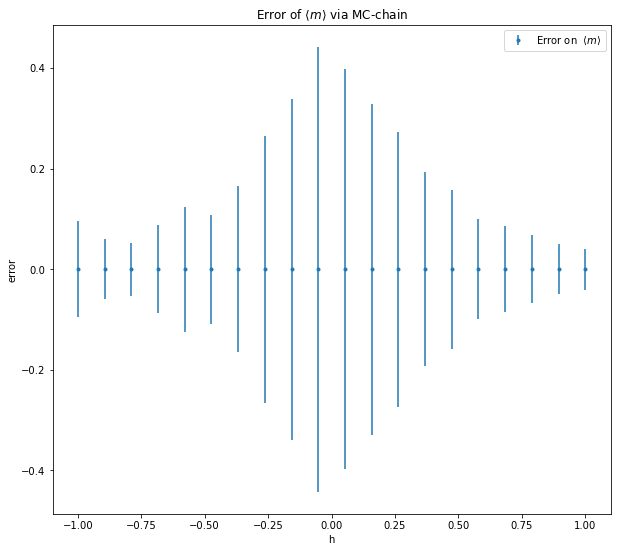

In [162]:
fig,ax =plt.subplots(figsize=(10,9))     
ax.errorbar(h,m_h,yerr = m_std, marker ='.', linestyle =' ', label =' MC m')
ax.set_xlabel('h')
ax.set_ylabel('⟨m⟩')
ax.plot(h,m(J,h), label = 'True m')
ax.legend()
plt.title('Calculation of $⟨m⟩$ via MC-chain')
plt.show()
fig,ax =plt.subplots(figsize=(10,9)) 
ax.errorbar(h,np.zeros(len(h)),yerr = m_std, marker ='.', linestyle =' ', label ='Error on  $⟨m⟩$')
ax.legend()
ax.set_xlabel('h')
ax.set_ylabel('error')
plt.title('Error of $⟨m⟩$ via MC-chain')
plt.show()

# Bootstraps


In [21]:
mc_time = 10
m_mc = np.zeros((20,mc_time))
for x in range(mc_time):
    J = 0.75 
    h = np.linspace(-1,1,20)
    N = 20
    sigma =  np.ones(20)
    m_mc[:,x] = MC(J,h,sigma,N)*N
    
def bootstrap(sample,size):
    x = np.random.choice(len(sample[0]), size)
    boot = sample[:,x]
    return boot


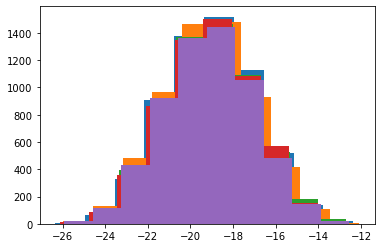

In [35]:
b =6000
q = np.zeros(b)
for z in range(5):
    for x in range(b):
        q[x] = bootstrap(m_mc,5).mean()-(bootstrap(m_mc,5)**2).mean()
    plt.hist(q)
plt.show()